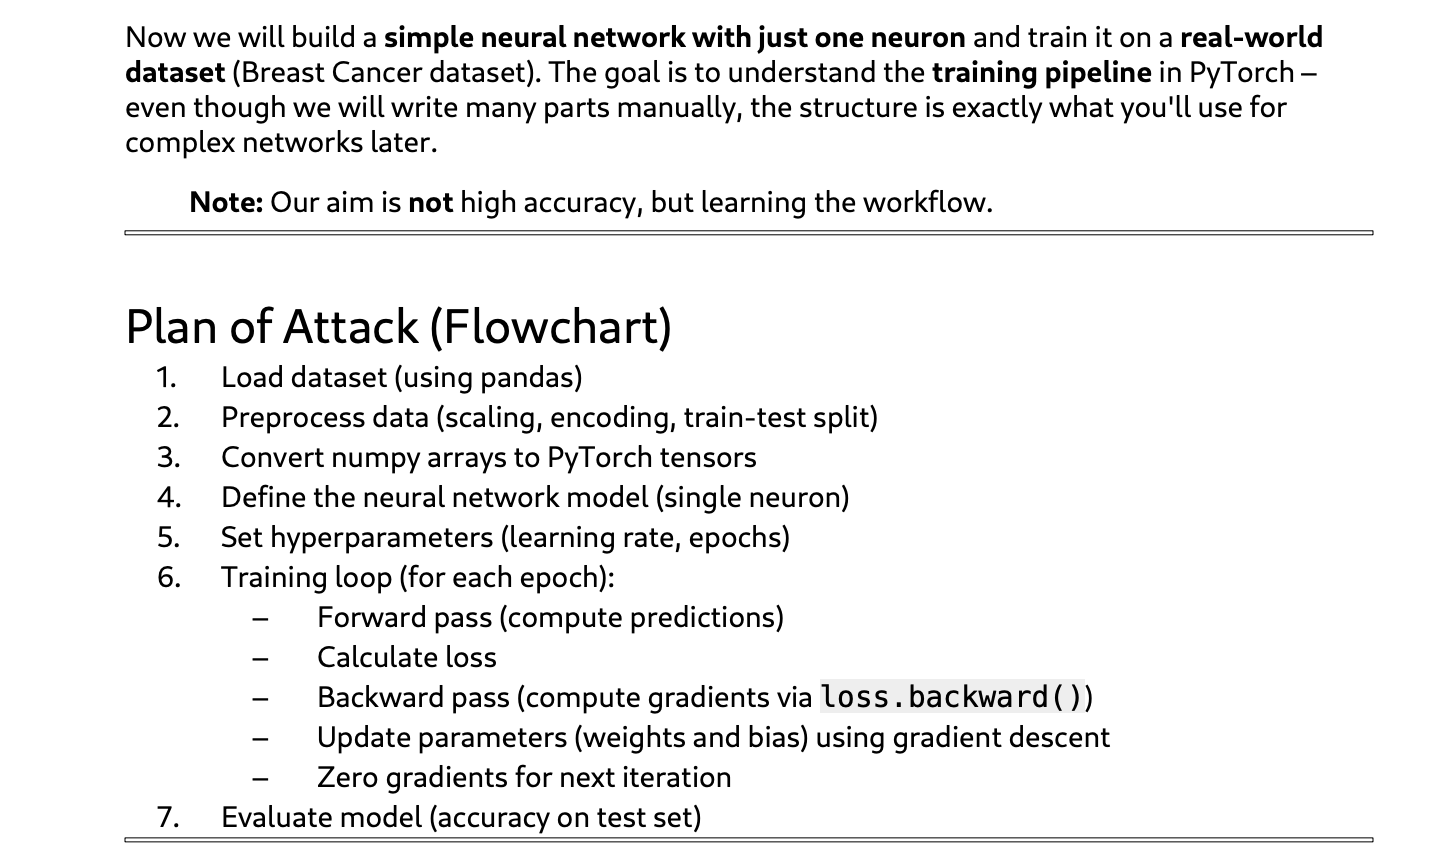

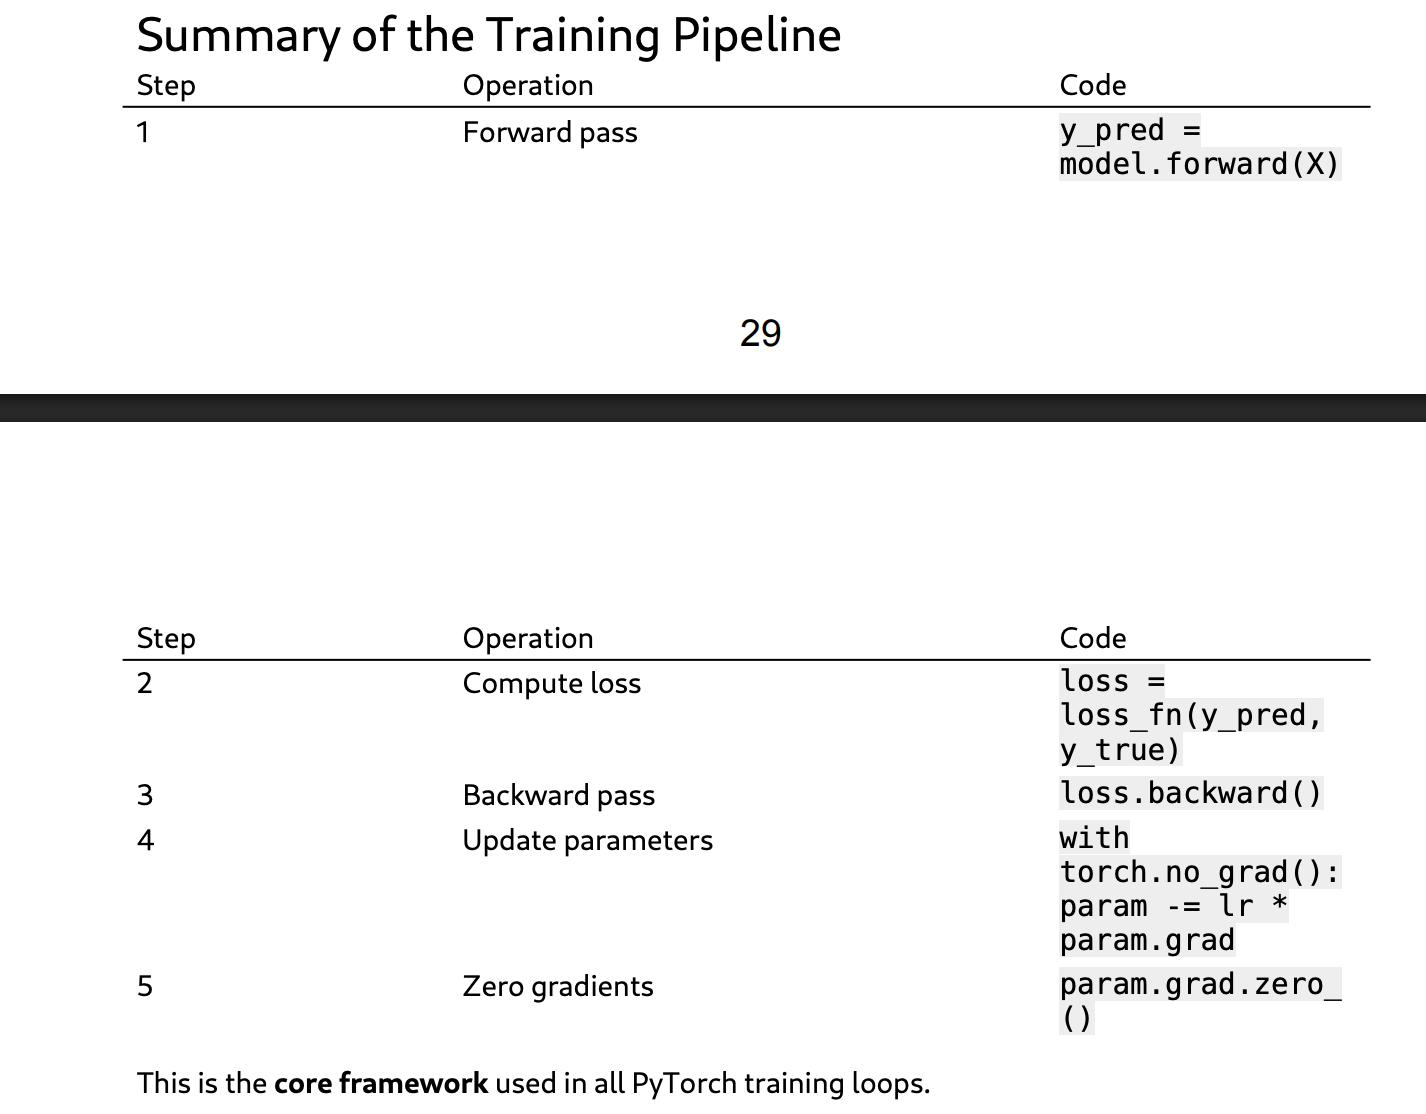

## Step 1: Load and Preprocess Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import torch

####  Load data

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.shape

(569, 33)

In [4]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

####  Drop unnecessary columns

In [5]:

df.drop(["id","Unnamed: 32"],axis="columns",inplace=True)
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

#### Split features and target

In [7]:
X=df.drop(["diagnosis"],axis="columns").values
y=df["diagnosis"].values

####  Train-test split

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#### Scale features (important for neural networks)

In [9]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [10]:
X_train

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]], shape=(455, 30))

In [11]:
X_test

array([[-0.46649743, -0.13728933, -0.44421138, ..., -0.19435087,
         0.17275669,  0.20372995],
       [ 1.36536344,  0.49866473,  1.30551088, ...,  0.99177862,
        -0.561211  , -1.00838949],
       [ 0.38006578,  0.06921974,  0.40410139, ...,  0.57035018,
        -0.10783139, -0.20629287],
       ...,
       [-0.73547237, -0.99852603, -0.74138839, ..., -0.27741059,
        -0.3820785 , -0.32408328],
       [ 0.02898271,  2.0334026 ,  0.0274851 , ..., -0.49027026,
        -1.60905688, -0.33137507],
       [ 1.87216885,  2.80077153,  1.80354992, ...,  0.7925579 ,
        -0.05868885, -0.09467243]], shape=(114, 30))

In [12]:
y_train

array(['B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M',
       'B', 'M', 'B', 'B', 'M', 'B', 'M', 'M', 'M', 'B', 'M', 'B', 'B',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B',
       'B', 'B', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'M', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B

#### Encode labels (M = malignant, B = benign) to 1 and 0

In [13]:
encoder=LabelEncoder()
y_train=encoder.fit_transform(y_train)
y_test=encoder.transform(y_test)

In [14]:
y_train

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,

#### Convert numpy arrays to PyTorch tensors

In [15]:
X_train_tensor=torch.from_numpy(X_train).float()
X_test_tensor=torch.from_numpy(X_test).float()
y_train_tensor=torch.from_numpy(y_train).float()
y_test_tensor=torch.from_numpy(y_test).float()

In [16]:
X_train_tensor.shape # 30 features

torch.Size([455, 30])

In [17]:
y_train_tensor.shape

torch.Size([455])

## Step 2: Define the Neural Network (Single Neuron)

We create a class MySimpleNeuralNetwork. The neuron has:
- 30 weights (one per input feature)
- 1 bias
We initialize weights randomly, bias to zero. Both require gradients (requires_grad=True).

In [18]:
torch.rand(size=(2,3))

tensor([[0.2005, 0.0336, 0.2696],
        [0.9622, 0.2580, 0.2328]])

In [19]:
import torch
import torch.nn as nn

# define class for model
class MySimpleNeuralNetwork(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(num_features,1),
            nn.Sigmoid()
        )
    
    
    def forward(self,features):
        out=self.network(features)
        return out

    


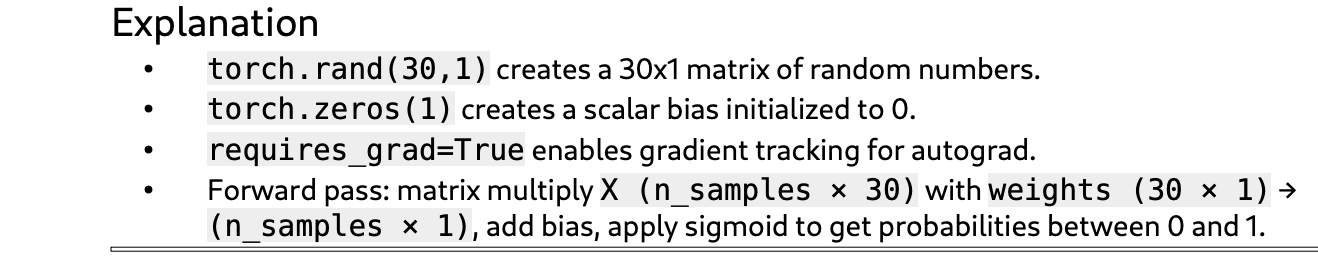

## Step 3: Hyperparameters

In [20]:
learning_rate=0.1
epochs=25

In [21]:
#define loss function
loss_function=nn.BCELoss()

In [22]:
type(loss_function)

torch.nn.modules.loss.BCELoss

## Step 6: Training Pipeline

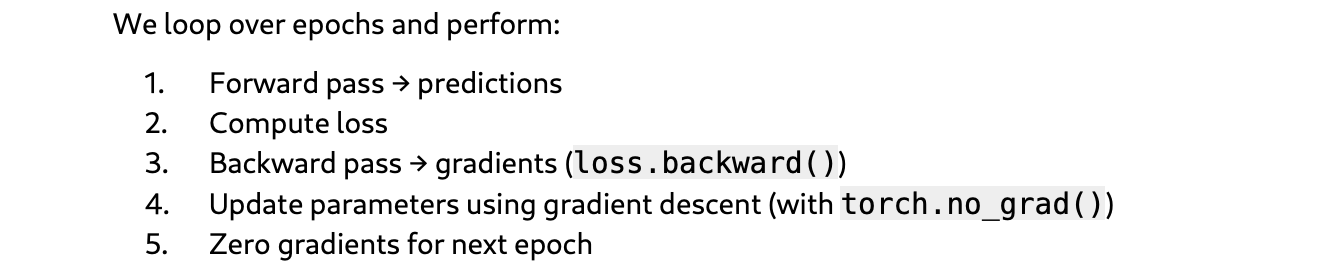

In [23]:
#create model
model=MySimpleNeuralNetwork(X_train_tensor.shape[1])

#define optimizer
optimizer=torch.optim.SGD(params=model.parameters(),lr=learning_rate)
# define loop
for epoch in range(epochs):
    #1.Forward pass
    y_pred=model(X_train_tensor)
    y_pred=y_pred.squeeze() #shape [455] to match y_train_tensor
    
    # 2. Calculate loss
    loss=loss_function(y_pred,y_train_tensor)
    
    # Zero gradients for next iteration(Recommended here for efficient)
    optimizer.zero_grad()
    # 3. Backward pass (compute gradients)
    loss.backward()

    # 4. Update parameters
    optimizer.step()

    

    #Print loss every epoch
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

Epoch 1/25, Loss: 0.7043110728263855
Epoch 2/25, Loss: 0.5652845501899719
Epoch 3/25, Loss: 0.4818263649940491
Epoch 4/25, Loss: 0.42620742321014404
Epoch 5/25, Loss: 0.38613107800483704
Epoch 6/25, Loss: 0.3556137979030609
Epoch 7/25, Loss: 0.33142513036727905
Epoch 8/25, Loss: 0.31166723370552063
Epoch 9/25, Loss: 0.2951488494873047
Epoch 10/25, Loss: 0.2810817062854767
Epoch 11/25, Loss: 0.26892146468162537
Epoch 12/25, Loss: 0.25827890634536743
Epoch 13/25, Loss: 0.24886773526668549
Epoch 14/25, Loss: 0.2404719740152359
Epoch 15/25, Loss: 0.23292554914951324
Epoch 16/25, Loss: 0.2260981947183609
Epoch 17/25, Loss: 0.2198861986398697
Epoch 18/25, Loss: 0.21420583128929138
Epoch 19/25, Loss: 0.20898844301700592
Epoch 20/25, Loss: 0.2041773647069931
Epoch 21/25, Loss: 0.19972506165504456
Epoch 22/25, Loss: 0.19559131562709808
Epoch 23/25, Loss: 0.191741943359375
Epoch 24/25, Loss: 0.18814755976200104
Epoch 25/25, Loss: 0.18478265404701233


## Step 7: Evaluation (Accuracy on Test Set)
We compute predictions on test data, convert probabilities to class labels using a threshold
(0.5), then calculate accuracy.

In [24]:
# Predict on test set (no gradients needed)
with torch.no_grad():
    y_pred=model(X_test_tensor).squeeze()
    #convert probabilities to 0/1 using threshold 0.5
    y_pred=(y_pred > 0.5).float()

#Calculate accuracy manually
correct=(y_pred==y_test_tensor).sum().item()
total=y_pred.shape[0]
accuracy=correct/total
print(f"test accuracy: {accuracy*100:.2f}%")

test accuracy: 98.25%
